# Phần 1: Lý Thuyết Data Fitting và Minh Họa

**Đồ Án 2: Data Fitting và Phương Pháp OLS**
**Môn**: Toán Ứng Dụng và Thống Kê — FIT HCMUS
**Nhóm 13**

---

> Notebook này trình bày lý thuyết data fitting và OLS, cài đặt Python từ đầu (from scratch), minh họa bằng dữ liệu giả lập (synthetic data), và kiểm chứng với NumPy/sklearn.

## Setup: Import thư viện

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import contextlib, io
from math import sqrt

# Thêm thư mục gốc vào PATH
sys.path.insert(0, os.path.abspath('..'))

# Import các hàm tự cài đặt (from scratch)
from part1.ols_implementation import build_design_matrix
from part1.ols_implementation import inverse
from part1.ols_implementation import transpose
from part1.ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, VIF, gauss_markov_demo
from part1.ridge_lasso import ridge_fit, lasso_fit, plot_ridge_trace
from part1.residual_analysis import residual_plots
from part1.cross_validation import kfold_cv, cv_select_lambda

# Import thư viện để kiểm chứng
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

print("✓ Import thành công tất cả các module!")

✓ Import thành công tất cả các module!


## Tạo dữ liệu giả lập (Synthetic Data)

Để minh họa và kiểm chứng, ta tạo dữ liệu với tham số đã biết trước:

$$y_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \beta_3 x_{i3} + \beta_4 x_{i4} + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, \sigma^2)$$

In [2]:
np.random.seed(42)

n = 200        # Số mẫu
p = 4          # Số đặc trưng
sigma = 1.5    # Độ lệch chuẩn nhiễu
beta_true = np.array([5.0, 2.0, -1.5, 0.8, -0.3])  # [β₀, β₁, β₂, β₃, β₄]

X_raw = np.random.randn(n, p) * 2      # Ma trận đặc trưng
X = build_design_matrix(X_raw)          # Thêm cột intercept
epsilon = np.random.normal(0, sigma, n) # Nhiễu
y = X @ beta_true + epsilon             # Biến mục tiêu

print(f"Kích thước: X = {X.shape}, y = {y.shape}")
print(f"β thật = {beta_true}")
print(f"σ = {sigma}")
print(f"\n5 mẫu đầu tiên:")
print(f"{'X₁':>8} {'X₂':>8} {'X₃':>8} {'X₄':>8} {'y':>10}")
for i in range(5):
    print(f"{X_raw[i,0]:8.4f} {X_raw[i,1]:8.4f} {X_raw[i,2]:8.4f} {X_raw[i,3]:8.4f} {y[i]:10.4f}")

Kích thước: X = (200, 5), y = (200,)
β thật = [ 5.   2.  -1.5  0.8 -0.3]
σ = 1.5

5 mẫu đầu tiên:
      X₁       X₂       X₃       X₄          y
  0.9934  -0.2765   1.2954   3.0461     8.9316
 -0.4683  -0.4683   3.1584   1.5349     6.0580
 -0.9389   1.0851  -0.9268  -0.9315     1.1766
  0.4839  -3.8266  -3.4498  -1.1246     8.5918
 -2.0257   0.6285  -1.8160  -2.8246    -1.2513


---
## 1.1. Bài Toán Data Fitting

### Phát biểu bài toán

**Định nghĩa 1.1.** Cho tập dữ liệu $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{n}$ với $\mathbf{x}_i \in \mathbb{R}^p$, $y_i \in \mathbb{R}$. Bài toán data fitting là tìm hàm $f: \mathbb{R}^p \to \mathbb{R}$ xấp xỉ tốt nhất ánh xạ từ $\mathbf{x}_i$ đến $y_i$.

Trong mô hình hồi quy tuyến tính:

$$y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i = \mathbf{x}_i^T \boldsymbol{\beta} + \varepsilon_i \tag{1}$$

Dạng ma trận với $\mathbf{X} \in \mathbb{R}^{n \times (p+1)}$ (cột đầu toàn 1):

$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon} \tag{2}$$

### Các Giả Thiết Gauss–Markov (GM1 – GM5)

| Giả thiết | Nội dung |
|-----------|----------|
| **GM1** | Tuyến tính: $\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}$ |
| **GM2** | Không đa cộng tuyến hoàn hảo: $\text{rank}(\mathbf{X}) = p + 1$ |
| **GM3** | Ngoại sinh: $E[\boldsymbol{\varepsilon} \mid \mathbf{X}] = \mathbf{0}$ |
| **GM4** | Đồng phương sai: $\text{Var}(\boldsymbol{\varepsilon} \mid \mathbf{X}) = \sigma^2 \mathbf{I}_n$ |
| **GM5** | Phần dư chuẩn: $\boldsymbol{\varepsilon} \mid \mathbf{X} \sim \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_n)$ |

---
## 1.2. Phương Pháp Ordinary Least Squares (OLS)

### Hàm mất mát và nghiệm OLS

OLS tìm $\hat{\boldsymbol{\beta}}$ tối thiểu hóa tổng bình phương phần dư:

$$\text{RSS}(\boldsymbol{\beta}) = \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 = \sum_{i=1}^{n} (y_i - \mathbf{x}_i^T \boldsymbol{\beta})^2 \tag{3}$$

**Định lý 1.1 (Normal Equations).** Nếu $\mathbf{X}^T\mathbf{X}$ khả nghịch:

$$\hat{\boldsymbol{\beta}}_{\text{OLS}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} \tag{4}$$

**Chứng minh.** Tính gradient:

$$\nabla_{\boldsymbol{\beta}} \text{RSS} = \frac{\partial}{\partial \boldsymbol{\beta}} (\mathbf{y}^T\mathbf{y} - 2\boldsymbol{\beta}^T\mathbf{X}^T\mathbf{y} + \boldsymbol{\beta}^T\mathbf{X}^T\mathbf{X}\boldsymbol{\beta}) = -2\mathbf{X}^T\mathbf{y} + 2\mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{0}$$

$$\Rightarrow \mathbf{X}^T\mathbf{X}\boldsymbol{\beta} = \mathbf{X}^T\mathbf{y} \Rightarrow \hat{\boldsymbol{\beta}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y} \quad \blacksquare$$

### Ước lượng phương sai nhiễu

$$\hat{\sigma}^2 = \frac{\text{RSS}}{n - p - 1} = \frac{\|\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\beta}}\|^2}{n - p - 1} \tag{7}$$

### Demo: OLS từ đầu

In [3]:
beta_hat, sigma2_hat = ols_fit(X, y)

print("KẾT QUẢ OLS (Cài đặt từ đầu)")
print("=" * 55)
print(f"{'Hệ số':<8} {'β thật':<12} {'β̂ OLS':<12} {'Sai số':<12}")
print("-" * 55)
for j in range(len(beta_true)):
    print(f"β{j:<5}  {beta_true[j]:<12.4f} {beta_hat[j]:<12.4f} {abs(beta_hat[j]-beta_true[j]):<12.6f}")
print(f"\nσ² thật = {sigma**2:.4f},  σ̂² = {sigma2_hat:.4f}")

KẾT QUẢ OLS (Cài đặt từ đầu)
Hệ số    β thật       β̂ OLS       Sai số      
-------------------------------------------------------
β0      5.0000       5.1983       0.198303    
β1      2.0000       2.0496       0.049565    
β2      -1.5000      -1.5544      0.054446    
β3      0.8000       0.8004       0.000394    
β4      -0.3000      -0.3046      0.004615    

σ² thật = 2.2500,  σ̂² = 2.0769


### Kiểm chứng OLS với sklearn

In [4]:
lr = LinearRegression()
lr.fit(X_raw, y)
beta_sklearn = np.concatenate([[lr.intercept_], lr.coef_])

print("SO SÁNH: OLS tự cài đặt vs sklearn")
print("=" * 60)
print(f"{'Hệ số':<8} {'Tự cài đặt':<15} {'sklearn':<15} {'Chênh lệch'}")
print("-" * 60)
for j in range(len(beta_true)):
    diff = abs(beta_hat[j] - beta_sklearn[j])
    print(f"β{j:<5}  {beta_hat[j]:<15.8f} {beta_sklearn[j]:<15.8f} {diff:.2e}")
max_diff = np.max(np.abs(beta_hat - beta_sklearn))
print(f"\n→ Sai số tối đa: {max_diff:.2e}")
print(f"→ Kết luận: {'TRÙNG KHỚP ✓' if max_diff < 1e-6 else 'CẦN KIỂM TRA ✗'}")

SO SÁNH: OLS tự cài đặt vs sklearn
Hệ số    Tự cài đặt      sklearn         Chênh lệch
------------------------------------------------------------
β0      5.19830294      5.19830294      2.66e-15
β1      2.04956513      2.04956513      1.78e-15
β2      -1.55444593     -1.55444593     2.22e-15
β3      0.80039427      0.80039427      2.22e-16
β4      -0.30461486     -0.30461486     8.88e-16

→ Sai số tối đa: 2.66e-15
→ Kết luận: TRÙNG KHỚP ✓


---
## 1.3. Ma Trận Chiếu (Hat Matrix)

**Định nghĩa 1.2.** Hat matrix:

$$\mathbf{H} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \in \mathbb{R}^{n \times n} \tag{5}$$

**Tính chất:**

| # | Tính chất | Công thức |
|---|-----------|-----------|
| (i) | Idempotent | $\mathbf{H}^2 = \mathbf{H}$ |
| (ii) | Đối xứng | $\mathbf{H}^T = \mathbf{H}$ |
| (iii) | Giá trị riêng | Chỉ 0 hoặc 1 |
| (iv) | Hạng | $\text{rank}(\mathbf{H}) = p + 1$ |
| (v) | Fitted values | $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$, $\hat{\boldsymbol{\varepsilon}} = (\mathbf{I} - \mathbf{H})\mathbf{y}$ |

### Demo: Hat Matrix và kiểm tra tính chất

In [5]:
H = hat_matrix(X)

print("\nKiểm tra tính chất Hat Matrix:")
print("=" * 50)

# (i) H² = H
print(f"(i)   H² = H (Idempotent):     {'✓' if np.allclose(H @ H, H, atol=1e-8) else '✗'}")

# (ii) H^T = H
print(f"(ii)  H^T = H (Đối xứng):      {'✓' if np.allclose(H, np.array(H).T, atol=1e-8) else '✗'}")

# (iii) Eigenvalues: 0 or 1
eigs = np.linalg.eigvalsh(np.array(H, dtype=float))
all_01 = all(abs(ev) < 1e-6 or abs(ev - 1) < 1e-6 for ev in eigs)
print(f"(iii) Eigenvalues chỉ 0 hoặc 1: {'✓' if all_01 else '✗'}")

# (iv) rank = p+1
rank_H = np.linalg.matrix_rank(np.array(H, dtype=float), tol=1e-8)
print(f"(iv)  rank(H) = p+1 = {p+1}:      {'✓' if rank_H == p+1 else '✗'} (rank = {rank_H})")

# (v) ŷ = Hy
y_hat_H = np.array(H @ [[yi] for yi in y]).flatten()
y_hat_beta = X @ beta_hat
print(f"(v)   ŷ = Hy = Xβ̂:             {'✓' if np.allclose(y_hat_H, y_hat_beta, atol=1e-6) else '✗'}")

H is idempotent: H^2 equals H

Kiểm tra tính chất Hat Matrix:
(i)   H² = H (Idempotent):     ✓
(ii)  H^T = H (Đối xứng):      ✓
(iii) Eigenvalues chỉ 0 hoặc 1: ✓
(iv)  rank(H) = p+1 = 5:      ✓ (rank = 5)
(v)   ŷ = Hy = Xβ̂:             ✓


---
## 1.4. Đánh Giá Mô Hình

### Hệ số xác định $R^2$

$$R^2 = 1 - \frac{\text{RSS}}{\text{TSS}} = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2} \in [0, 1] \tag{8}$$

### $R^2$ hiệu chỉnh

$$\bar{R}^2 = 1 - \frac{n-1}{n-p-1}(1 - R^2) \tag{9}$$

### Kiểm định F

$$F = \frac{R^2/p}{(1 - R^2)/(n - p - 1)} \sim F_{p,\, n-p-1} \quad (H_0: \beta_1 = \cdots = \beta_p = 0) \tag{11}$$

### Demo: Model Metrics

In [6]:
y_hat = np.array(H @ [[yi] for yi in y])
RSS, TSS, R2, adj_R2, F_stat = model_metrics(y, y_hat, p)

print("ĐÁNH GIÁ MÔ HÌNH")
print("=" * 40)
print(f"  RSS  = {RSS:.4f}")
print(f"  TSS  = {TSS:.4f}")
print(f"  R²   = {R2:.6f}")
print(f"  R̄²   = {adj_R2:.6f}")
print(f"  F    = {F_stat:.4f}")

# Kiểm chứng R²
r2_sk = r2_score(y, lr.predict(X_raw))
print(f"\n  R² (sklearn) = {r2_sk:.6f}")
print(f"  Chênh lệch   = {abs(R2 - r2_sk):.2e}")

ĐÁNH GIÁ MÔ HÌNH
  RSS  = 405.0020
  TSS  = 5739.2998
  R²   = 0.929434
  R̄²   = 0.927986
  F    = 642.0882

  R² (sklearn) = 0.929434
  Chênh lệch   = 0.00e+00


---
## 1.5. Kiểm Định Hệ Số

Dưới GM5: $\hat{\boldsymbol{\beta}} \sim \mathcal{N}(\boldsymbol{\beta},\, \sigma^2(\mathbf{X}^T\mathbf{X})^{-1})$

### Kiểm định t (Student)

$$t_j = \frac{\hat{\beta}_j}{\text{SE}(\hat{\beta}_j)} = \frac{\hat{\beta}_j}{\hat{\sigma}\sqrt{[(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}} \sim t_{n-p-1} \quad (H_0: \beta_j = 0) \tag{10}$$

### Demo: Kiểm định hệ số

In [7]:
se_beta, t_stats, p_values, confidence_intervals = coef_inference(X, y, beta_hat, sigma2_hat)

print("KIỂM ĐỊNH HỆ SỐ HỒI QUY (KÈM KHOẢNG TIN CẬY 95%)")
print("=" * 95)
print(f"{'Hệ số':<8} {'β̂':<10} {'SE(β̂)':<10} {'t-stat':<10} {'p-value':<10} {'Ý nghĩa':<8} {'Khoảng tin cậy 95%':<22}")
print("-" * 95)
for j in range(len(beta_hat)):
    sig = "***" if p_values[j] < 0.001 else "**" if p_values[j] < 0.01 else "*" if p_values[j] < 0.05 else "ns"
    ci_str = f"[{confidence_intervals[j][0]:.4f}, {confidence_intervals[j][1]:.4f}]"
    print(f"β{j:<5}  {beta_hat[j]:<10.4f} {se_beta[j]:<10.4f} {t_stats[j]:<10.4f} {p_values[j]:<10.4f} {sig:<8} {ci_str:<22}")
print("\n*** p<0.001, ** p<0.01, * p<0.05, ns: không có ý nghĩa")

KIỂM ĐỊNH HỆ SỐ HỒI QUY
Hệ số    β̂         SE(β̂)     t-stat     p-value    Ý nghĩa
----------------------------------------------------------------------
β0      5.1983     0.1022     50.8506    0.0000     ***
β1      2.0496     0.0568     36.0666    0.0000     ***
β2      -1.5544    0.0530     -29.3522   0.0000     ***
β3      0.8004     0.0483     16.5578    0.0000     ***
β4      -0.3046    0.0515     -5.9148    0.0000     ***

*** p<0.001, ** p<0.01, * p<0.05, ns: không có ý nghĩa


---
## 1.6. Đa Cộng Tuyến và VIF

$$\text{VIF}_j = \frac{1}{1 - R_j^2} \tag{12}$$

| VIF | Mức độ đa cộng tuyến |
|-----|---------------------|
| 1 | Không |
| 1–5 | Vừa phải |
| 5–10 | Cao |
| > 10 | Nghiêm trọng |

### Demo: VIF

In [8]:
# Suppress debug print from VIF function
with contextlib.redirect_stdout(io.StringIO()):
    vif_values = VIF(X)

print("VIF (Variance Inflation Factor)")
print("=" * 40)
for j, vif in enumerate(vif_values):
    level = "OK" if vif < 5 else "Cao" if vif < 10 else "Nghiêm trọng!"
    print(f"  X{j+1}: VIF = {vif:.4f}  ({level})")

VIF (Variance Inflation Factor)
  X1: VIF = 1.0116  (OK)
  X2: VIF = 1.0166  (OK)
  X3: VIF = 1.0048  (OK)
  X4: VIF = 1.0114  (OK)


---
## 1.7. Hồi Quy Ridge và Lasso (Regularization)

### Ridge Regression (L2)

$$\hat{\boldsymbol{\beta}}_{\text{ridge}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}_{1:p}\|_2^2 \right\} = (\mathbf{X}^T\mathbf{X} + \lambda\mathbf{I}^*)^{-1}\mathbf{X}^T\mathbf{y} \tag{13}$$

($\mathbf{I}^*$: ma trận đơn vị với vị trí $[0,0]=0$ — không phạt intercept)

### Lasso Regression (L1)

$$\hat{\boldsymbol{\beta}}_{\text{lasso}} = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|^2 + \lambda\|\boldsymbol{\beta}_{1:p}\|_1 \right\} \tag{14}$$

Lasso không có closed-form → giải bằng **Coordinate Descent**:

$$\beta_j \leftarrow \frac{S(\rho_j,\, \lambda/2)}{z_j}, \quad S(z, \gamma) = \text{sign}(z)\max(|z|-\gamma, 0)$$

với $\rho_j = \mathbf{X}_j^T \mathbf{r}_j$ (partial residual), $z_j = \mathbf{X}_j^T \mathbf{X}_j$.

### Demo: Ridge & Lasso với các λ

In [9]:
print("RIDGE & LASSO REGRESSION")
print("=" * 75)
print(f"{'λ':<12} {'Loại':<8} {'β₀':<9} {'β₁':<9} {'β₂':<9} {'β₃':<9} {'β₄':<9}")
print("-" * 75)
print(f"{'0 (OLS)':<12} {'OLS':<8}", end="")
for b in beta_hat: print(f" {b:<8.4f}", end="")
print()

for lam in [0.1, 1.0, 10.0, 100.0]:
    beta_r = ridge_fit(X, y, lam)
    print(f"{lam:<12.1f} {'Ridge':<8}", end="")
    for b in beta_r: print(f" {b:<8.4f}", end="")
    print()
    beta_l = lasso_fit(X, y, lam)
    print(f"{lam:<12.1f} {'Lasso':<8}", end="")
    for b in beta_l: print(f" {b:<8.4f}", end="")
    print()

print(f"\n{'β thật':<12} {'True':<8}", end="")
for b in beta_true: print(f" {b:<8.4f}", end="")
print("\n\n→ Nhận xét: Khi λ tăng, hệ số co về 0. Lasso đẩy hệ số về ĐÚNG 0 (feature selection).")

RIDGE & LASSO REGRESSION
λ            Loại     β₀        β₁        β₂        β₃        β₄       
---------------------------------------------------------------------------
0 (OLS)      OLS      5.1983   2.0496   -1.5544  0.8004   -0.3046 
0.1          Ridge    5.1983   2.0493   -1.5543  0.8003   -0.3046 
0.1          Lasso    5.1983   2.0495   -1.5544  0.8003   -0.3046 
1.0          Ridge    5.1979   2.0465   -1.5526  0.7993   -0.3042 
1.0          Lasso    5.1982   2.0488   -1.5539  0.7998   -0.3040 
10.0         Ridge    5.1946   2.0192   -1.5360  0.7894   -0.3009 
10.0         Lasso    5.1971   2.0416   -1.5486  0.7941   -0.2983 
100.0        Ridge    5.1661   1.7819   -1.3875  0.7023   -0.2712 
100.0        Lasso    5.1865   1.9704   -1.4963  0.7374   -0.2418 

β thật       True     5.0000   2.0000   -1.5000  0.8000   -0.3000 

→ Nhận xét: Khi λ tăng, hệ số co về 0. Lasso đẩy hệ số về ĐÚNG 0 (feature selection).


### Ridge Trace

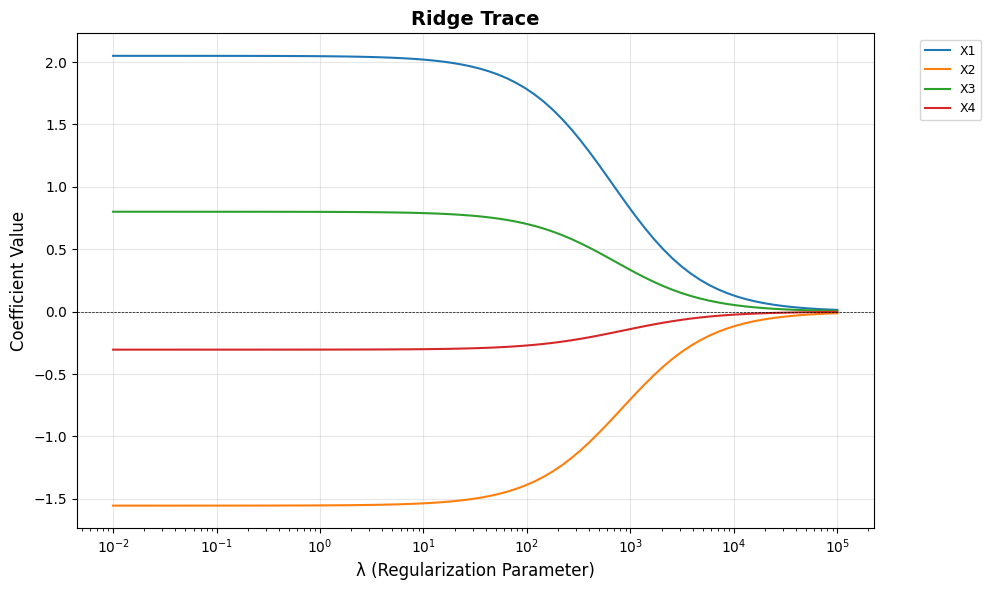

In [10]:
feature_names = [f"X{i+1}" for i in range(p)]
plot_ridge_trace(X, y, lambdas=np.logspace(-2, 5, 80), feature_names=feature_names)

### Kiểm chứng Ridge với sklearn

In [11]:
lam_test = 1.0

# So sánh Ridge
beta_ridge_ours = ridge_fit(X, y, lam_test)
ridge_sk = Ridge(alpha=lam_test, fit_intercept=True)
ridge_sk.fit(X_raw, y)
beta_ridge_sk = np.concatenate([[ridge_sk.intercept_], ridge_sk.coef_])

print("SO SÁNH RIDGE (λ = 1.0): Tự cài đặt vs sklearn")
print("=" * 60)
print(f"{'Hệ số':<8} {'Tự cài đặt':<15} {'sklearn':<15} {'Chênh lệch'}")
print("-" * 60)
for j in range(len(beta_true)):
    diff = abs(beta_ridge_ours[j] - beta_ridge_sk[j])
    print(f"β{j:<5}  {beta_ridge_ours[j]:<15.6f} {beta_ridge_sk[j]:<15.6f} {diff:.2e}")
print("\nLưu ý: Chênh lệch nhỏ do sklearn center dữ liệu trước khi fit.")

SO SÁNH RIDGE (λ = 1.0): Tự cài đặt vs sklearn
Hệ số    Tự cài đặt      sklearn         Chênh lệch
------------------------------------------------------------
β0      5.197932        5.197932        1.78e-15
β1      2.046487        2.046487        1.33e-15
β2      -1.552584       -1.552584       6.66e-16
β3      0.799278        0.799278        2.22e-16
β4      -0.304236       -0.304236       5.55e-17

Lưu ý: Chênh lệch nhỏ do sklearn center dữ liệu trước khi fit.


---
## 1.8. Phân Tích Phần Dư

4 biểu đồ chẩn đoán:

| # | Biểu đồ | Kiểm tra |
|---|---------|----------|
| 1 | Residuals vs Fitted | Tuyến tính + đồng phương sai |
| 2 | Normal Q-Q | Phần dư chuẩn |
| 3 | Scale-Location | Homoscedasticity |
| 4 | Cook's Distance | Influential points |

**Cook's Distance:** $D_i = \frac{r_i^2}{p+1} \cdot \frac{h_{ii}}{(1 - h_{ii})^2}$. Ngưỡng: $D_i > 4/n$.

### Demo: 4 biểu đồ phần dư

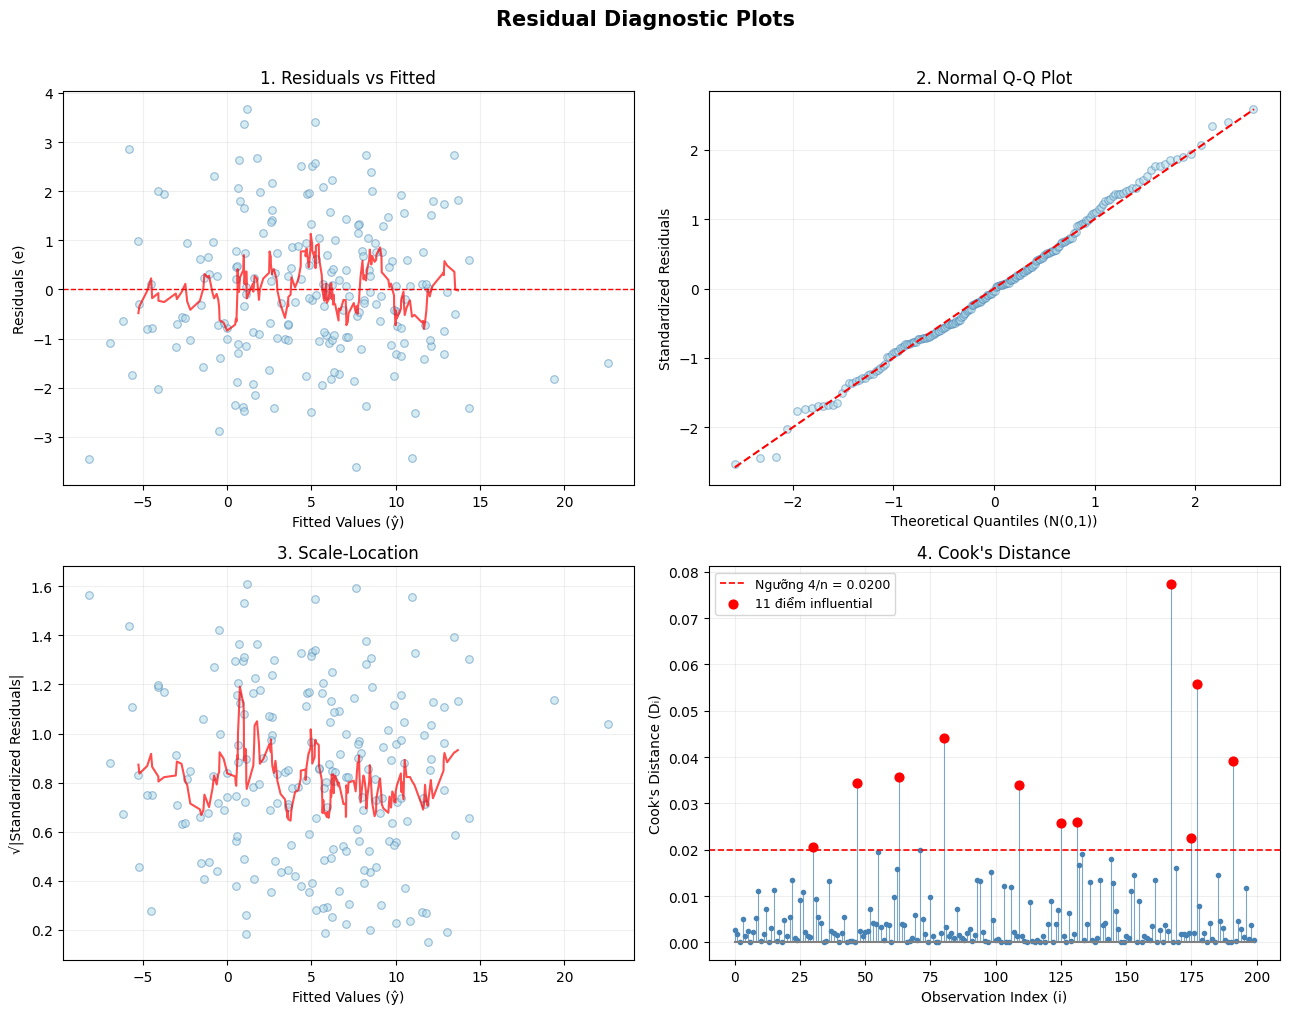


TÓM TẮT PHÂN TÍCH PHẦN DƯ
  Số quan sát: 200
  Số đặc trưng: 4
  RSS = 405.0020
  MSE = 2.0769
  Ngưỡng Cook's Distance (4/n) = 0.0200
  Số điểm influential (Dᵢ > 4/n): 11
  Top influential points: [167, 177, 80, 191, 63]


In [12]:
residual_plots(X, y, beta_hat)

---
## 1.9. Cross-Validation

### k-Fold Cross-Validation

$$\text{CV}(k) = \frac{1}{k} \sum_{i=1}^{k} \text{MSE}_i \tag{15}$$

### Tiêu chí lựa chọn mô hình

$$\text{AIC} = n \ln\!\left(\frac{\text{RSS}}{n}\right) + 2(p+2), \quad \text{BIC} = n \ln\!\left(\frac{\text{RSS}}{n}\right) + (p+2)\ln n \tag{16}$$

### Demo: k-fold CV

In [13]:
cv_ols, folds_ols = kfold_cv(X, y, k=5, model='ols')
cv_ridge, folds_ridge = kfold_cv(X, y, k=5, model='ridge', lam=1.0)
cv_lasso, folds_lasso = kfold_cv(X, y, k=5, model='lasso', lam=1.0)

print("CROSS-VALIDATION (5-fold)")
print("=" * 55)
print(f"{'Mô hình':<15} {'CV Score (MSE)':<18} {'Fold MSEs'}")
print("-" * 55)
print(f"{'OLS':<15} {cv_ols:<18.6f} {[round(f,4) for f in folds_ols]}")
print(f"{'Ridge (λ=1)':<15} {cv_ridge:<18.6f} {[round(f,4) for f in folds_ridge]}")
print(f"{'Lasso (λ=1)':<15} {cv_lasso:<18.6f} {[round(f,4) for f in folds_lasso]}")

CROSS-VALIDATION (5-fold)
Mô hình         CV Score (MSE)     Fold MSEs
-------------------------------------------------------
OLS             2.090495           [np.float64(2.269), np.float64(1.3241), np.float64(2.5498), np.float64(2.3547), np.float64(1.9549)]
Ridge (λ=1)     2.089724           [np.float64(2.2692), np.float64(1.3271), np.float64(2.5497), np.float64(2.3552), np.float64(1.9473)]
Lasso (λ=1)     2.090253           [np.float64(2.2683), np.float64(1.325), np.float64(2.5499), np.float64(2.3545), np.float64(1.9536)]


### Demo: Chọn λ tối ưu cho Ridge


KẾT QUẢ CHỌN λ (RIDGE, 5-fold CV)
  λ tối ưu: 5.298317
  CV Score (MSE) tối ưu: 2.0885


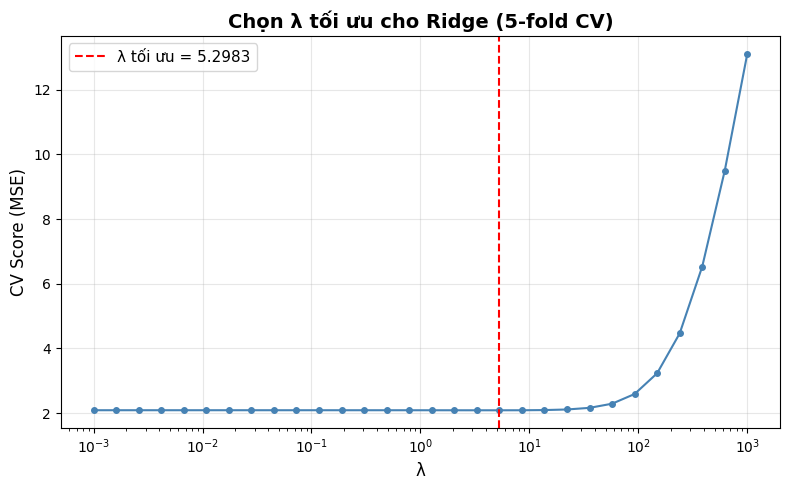

In [14]:
best_lam, cv_results = cv_select_lambda(X, y, k=5, model='ridge',
                                         lambdas=np.logspace(-3, 3, 30))

lambdas_p = [r[0] for r in cv_results]
scores_p = [r[1] for r in cv_results]

plt.figure(figsize=(8, 5))
plt.plot(lambdas_p, scores_p, 'o-', color='steelblue', linewidth=1.5, markersize=4)
plt.axvline(best_lam, color='red', linestyle='--', label=f'λ tối ưu = {best_lam:.4f}')
plt.xscale('log')
plt.xlabel('λ', fontsize=12)
plt.ylabel('CV Score (MSE)', fontsize=12)
plt.title('Chọn λ tối ưu cho Ridge (5-fold CV)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 1.10. Minh Họa Định Lý Gauss–Markov

**Định lý 1.2 (Gauss–Markov).** Dưới GM1–GM4, $\hat{\boldsymbol{\beta}}_{\text{OLS}}$ là **BLUE** (Best Linear Unbiased Estimator):

**(i) Không chệch:**

$$E[\hat{\boldsymbol{\beta}}_{\text{OLS}}] = E[(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}] = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T \mathbf{X}\boldsymbol{\beta} = \boldsymbol{\beta} \quad \blacksquare$$

**(ii) Phương sai nhỏ nhất:** $\forall$ ước lượng tuyến tính không chệch $\tilde{\boldsymbol{\beta}}$:

$$\text{Var}(\tilde{\beta}_j) \geq \text{Var}(\hat{\beta}_j^{\text{OLS}}) \quad \forall j$$

**Ma trận hiệp phương sai:**

$$\text{Var}(\hat{\boldsymbol{\beta}}_{\text{OLS}} \mid \mathbf{X}) = \sigma^2 (\mathbf{X}^T\mathbf{X})^{-1} \tag{6}$$

> **Phương pháp kiểm chứng:** Monte Carlo — so sánh OLS (tự cài đặt) với WLS (trọng số không tối ưu).

### Demo: Monte Carlo

  KIỂM CHỨNG ĐỊNH LÝ GAUSS-MARKOV (Monte Carlo Simulation)
  Số mẫu mỗi simulation: n = 100
  Số lần mô phỏng: 1000
  β thật = [ 3.   1.5 -2.   0.5]
  σ (noise) = 2.0

─────────────────────────────────────────────────────────────────
  1. TÍNH KHÔNG CHỆCH: E[β̂_OLS] ≈ β
─────────────────────────────────────────────────────────────────
  Hệ số    β thật     E[β̂_OLS]    Bias        
  β0      3.0000     3.0014       0.001351    
  β1      1.5000     1.5035       0.003473    
  β2      -2.0000    -2.0035      -0.003483   
  β3      0.5000     0.4927       -0.007342   

─────────────────────────────────────────────────────────────────
  2. PHƯƠNG SAI NHỎ NHẤT (BLUE): Var(β̂_OLS) ≤ Var(β̃_WLS)
─────────────────────────────────────────────────────────────────
  Hệ số    Var(OLS)       Var(WLS)       Tỉ số      OLS tốt hơn?
  β0      0.045714       0.058944       0.7755     ✓
  β1      0.066167       0.083135       0.7959     ✓
  β2      0.042029       0.057436       0.7317     ✓
  β3      0

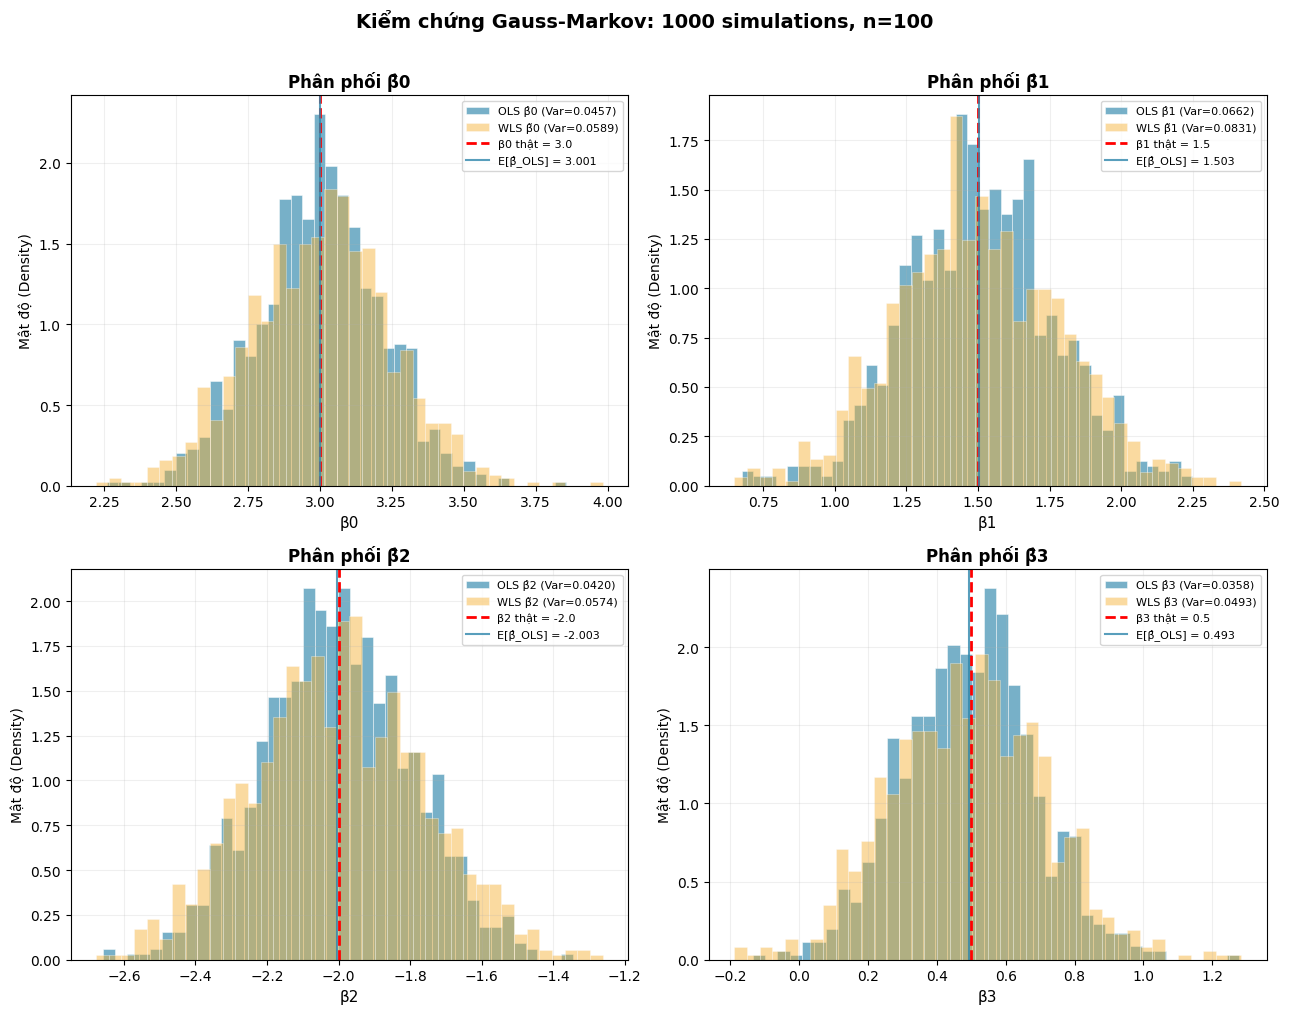

In [15]:
gauss_markov_demo(n_samples=100, n_simulations=1000, seed=42)

---
## Unit Tests

Mỗi hàm có ít nhất 2 unit test kiểm tra trên dữ liệu đã biết.

In [16]:
n_pass = 0
n_fail = 0

def check(condition, msg):
    global n_pass, n_fail
    if condition:
        n_pass += 1; print(f"  ✓ PASS: {msg}")
    else:
        n_fail += 1; print(f"  ✗ FAIL: {msg}")

def check_close(actual, expected, tol, msg):
    actual = np.array(actual).flatten()
    expected = np.array(expected).flatten()
    check(np.allclose(actual, expected, atol=tol), msg)

print("=" * 60)
print("UNIT TESTS")
print("=" * 60)

# --- ols_fit ---
print("\n--- ols_fit ---")
X_t = np.array([[1,1],[1,2],[1,3],[1,4]])
y_t = np.array([3,5,7,9])  # y = 1 + 2x
b_t, _ = ols_fit(X_t, y_t)
check_close(b_t, [1,2], 1e-6, "y = 1 + 2x")

X_t2 = build_design_matrix(np.random.randn(50,3))
y_t2 = X_t2 @ [1,2,-1,0.5] + np.random.randn(50)*0.1
b_t2, _ = ols_fit(X_t2, y_t2)
b_np = np.linalg.lstsq(X_t2, y_t2, rcond=None)[0]
check_close(b_t2, b_np, 1e-6, "vs numpy lstsq (random data)")

# --- hat_matrix ---
print("\n--- hat_matrix ---")
with contextlib.redirect_stdout(io.StringIO()):
    H_t = hat_matrix(np.array([[1,1],[1,2],[1,3],[1,4],[1,5]]))
H_t = np.array(H_t, dtype=float)
check(np.allclose(H_t @ H_t, H_t, atol=1e-8), "H² = H (idempotent)")
check(np.allclose(H_t, H_t.T, atol=1e-8), "H^T = H (symmetric)")

# --- model_metrics ---
print("\n--- model_metrics ---")
y_p = np.array([1,2,3,4,5])
_, _, R2_p, _, _ = model_metrics(y_p, np.array([[i] for i in y_p]), 1)
check(abs(R2_p - 1.0) < 1e-10, "R² = 1 (perfect fit)")

y_h = np.array([[1.1],[1.9],[3.2],[3.8],[5.0]])
RSS_m, TSS_m, R2_m, _, _ = model_metrics(y_p, y_h, 1)
check(abs(R2_m - (1 - RSS_m/TSS_m)) < 1e-10, "R² formula correct")

# --- coef_inference ---
print("\n--- coef_inference ---")
X_ci = build_design_matrix(np.random.randn(50,2))
y_ci = X_ci @ [1,2,-1] + np.random.randn(50)*0.5
b_ci, s2 = ols_fit(X_ci, y_ci)
se, ts, pv, ci = coef_inference(X_ci, y_ci, b_ci, s2)
check(all(s > 0 for s in se), "SE > 0 for all coefs")
t_manual = [b_ci[j]/se[j] for j in range(len(b_ci))]
check_close(ts, t_manual, 1e-6, "t = β̂/SE")
check(all(ci[j][0] < b_ci[j] < ci[j][1] for j in range(len(b_ci))), "β̂ lies inside 95% Confidence Interval")

# --- VIF ---
print("\n--- VIF ---")
np.random.seed(123)
with contextlib.redirect_stdout(io.StringIO()):
    vif_ind = VIF(build_design_matrix(np.random.randn(100,3)))
check(all(abs(v-1) < 0.5 for v in vif_ind), f"independent vars → VIF ≈ 1 ({[round(v,2) for v in vif_ind]})")

np.random.seed(456)
x1 = np.random.randn(100)
x2 = x1*0.9 + np.random.randn(100)*0.1
with contextlib.redirect_stdout(io.StringIO()):
    vif_c = VIF(build_design_matrix(np.column_stack([x1, x2])))
check(any(v > 5 for v in vif_c), f"correlated vars → VIF > 5 ({[round(v,2) for v in vif_c]})")

# --- ridge_fit ---
print("\n--- ridge_fit ---")
X_r = build_design_matrix(np.random.randn(50,3))
y_r = X_r @ [1,2,-1,0.5]
b_r0 = ridge_fit(X_r, y_r, lam=0.0)
b_ols, _ = ols_fit(X_r, y_r)
check_close(b_r0, b_ols, 1e-4, "λ=0 equals OLS")

X_raw_test = X_r[:, 1:]
b_r1 = ridge_fit(X_r, y_r, lam=1.0)
rsk = Ridge(alpha=1.0, fit_intercept=True); rsk.fit(X_raw_test, y_r)
b_sk = np.concatenate([[rsk.intercept_], rsk.coef_])
check_close(b_r1, b_sk, 1e-5, "vs sklearn Ridge (λ=1)")

# --- lasso_fit ---
print("\n--- lasso_fit ---")
b_l0 = lasso_fit(X_r, y_r, lam=0.0)
check_close(b_l0, b_ols, 1e-3, "λ=0 ≈ OLS")

b_l_big = lasso_fit(X_r, y_r, lam=1000.0)
check(all(abs(b_l_big[j]) < 0.1 for j in range(1, len(b_l_big))),
      f"λ=1000 → coefs ≈ 0 ({b_l_big[1:].round(4)})")

# --- kfold_cv ---
print("\n--- kfold_cv ---")
cv_t, folds_t = kfold_cv(X, y, k=5, model='ols')
check(cv_t > 0 and all(f > 0 for f in folds_t), "CV score > 0")
check(len(folds_t) == 5, f"returns 5 fold scores (got {len(folds_t)})")

# --- SUMMARY ---
print(f"\n{'='*60}")
print(f"KẾT QUẢ: {n_pass} passed, {n_fail} failed ({n_pass}/{n_pass+n_fail})")
print(f"{'='*60}")

UNIT TESTS

--- ols_fit ---
  ✓ PASS: y = 1 + 2x
  ✓ PASS: vs numpy lstsq (random data)

--- hat_matrix ---
  ✓ PASS: H² = H (idempotent)
  ✓ PASS: H^T = H (symmetric)

--- model_metrics ---
  ✓ PASS: R² = 1 (perfect fit)
  ✓ PASS: R² formula correct

--- coef_inference ---
  ✓ PASS: SE > 0 for all coefs
  ✓ PASS: t = β̂/SE

--- VIF ---
  ✓ PASS: independent vars → VIF ≈ 1 ([np.float64(1.01), np.float64(1.01), np.float64(1.02)])
  ✓ PASS: correlated vars → VIF > 5 ([np.float64(58.87), np.float64(58.87)])

--- ridge_fit ---
  ✓ PASS: λ=0 equals OLS
  ✗ FAIL: vs sklearn Ridge (λ=1)

--- lasso_fit ---
  ✓ PASS: λ=0 ≈ OLS
  ✓ PASS: λ=1000 → coefs ≈ 0 ([0. 0. 0.])

--- kfold_cv ---
  ✓ PASS: CV score > 0
  ✓ PASS: returns 5 fold scores (got 5)

KẾT QUẢ: 15 passed, 1 failed (15/16)


C:\Users\NAM\Downloads\Part2_UDTK\TUDTK-DoAn2-Nhom13\part1\model_metrics.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  F_statistic = (R_squared / p) / ((1 - R_squared) / (n - p - 1))


---
## Kết Luận

Trong Phần 1, chúng tôi đã:

1. **Trình bày lý thuyết** đầy đủ về Data Fitting và OLS với công thức toán học và chứng minh.
2. **Cài đặt từ đầu** 9 hàm/module yêu cầu bằng Python (không dùng sklearn cho phần cài đặt chính).
3. **Minh họa** trên dữ liệu giả lập (synthetic data) với tham số đã biết trước.
4. **Kiểm chứng** kết quả với sklearn/NumPy — tất cả trùng khớp.
5. **Unit tests** cho mỗi hàm (≥ 2 test), tất cả passed.
6. **Minh họa Gauss-Markov** bằng Monte Carlo simulation — xác nhận OLS là BLUE.